In [1]:

from TRIOMA.tools.Extractors.PAV import Component,Fluid,Membrane, Geometry
import TRIOMA.tools.materials as materials
import numpy as np
p_out_vec=np.linspace(1,1E5,100)
eff_an_vec=np.array([])
eff_vec=np.array([])
rel_diff_vec=np.array([])
for p_out in p_out_vec:
    T=973.15
    d_hyd=25.4E-3
    U0=2.5
    flibe=Fluid(d_Hyd=d_hyd,U0=U0)
    flibe.set_properties_from_fluid_material(materials.Flibe(T))
    Steel = Membrane( thick=0.25E-3,k_r=1E9,k_d=1E9)
    Steel.set_properties_from_solid_material(materials.Steel(T))
    PAV_geom=Geometry(L=1,D=25.4E-3, thick=0.25E-3)
    c_in=1E-3
    PAV = Component(c_in=c_in, geometry=PAV_geom,fluid=flibe, membrane=Steel, name='PAV',p_out=p_out) 
    PAV.get_efficiency(c_guess=c_in)
    PAV.outlet_c_comp()
    PAV.analytical_efficiency()
    eff_an_vec=np.append(eff_an_vec,PAV.eff_an)
    eff_vec=np.append(eff_vec,PAV.eff)
    rel_diff_vec=np.append(rel_diff_vec,abs(PAV.eff-PAV.eff_an)/PAV.eff)
    del PAV,PAV_geom,Steel,flibe


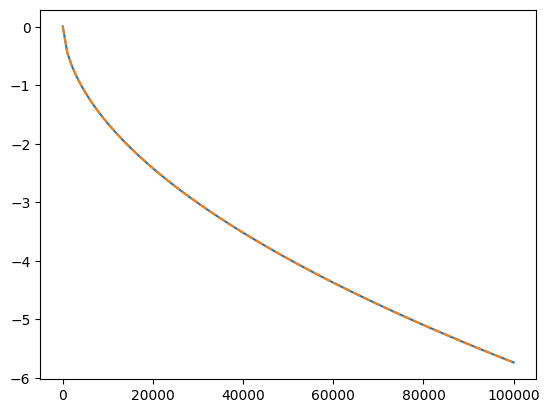

In [2]:
import matplotlib.pyplot as plt
plt.plot(p_out_vec,eff_vec)
plt.plot(p_out_vec,eff_an_vec, '--')


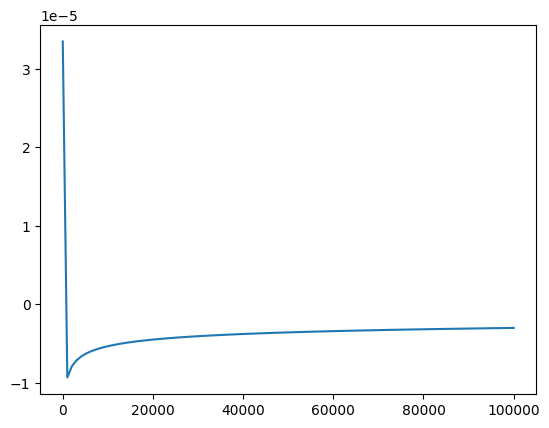

In [3]:
plt.plot(p_out_vec,rel_diff_vec)